# Exercise 4

This exercise is based on Chapter 14 and the beginning of Chaprt 15 of "Computational and Inferential Thinking: The Foundations of Data Science."

The material can be found in Jupyter notebooks in GSP538/ds_book/chapters/15/ and GSP538/ds_book/chapters/15/.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. Why are means sensitive to outliers, but medians are not?

2. When will the mean and median be almost equal? 

3. In a $2x2$ correlation matrix, the numbers in the upper-left and lower-right will be identical; the numbers in the lower-left and upper-right will also be identical. Why is this and what are the possible values for each pair?

4. The book talks about sampling with-replacement and without-replacement. What is the difference between these two methods? When you are sampling from a very large pool, why does it not matter much if you use the with-replacement or without-replacement approach?

5. The book mentions that ecological correlations can be problematic. In your own words, what should we be concerned about? (Hint: you might want to read about "ecological fallacy" to get more background on this.)

6. The book discussed medians, percentiles and the spread of data. A common way of combining and representing those concepts is the "inter quartile range" (IQR) and the "box plot." Read the following webpage https://discovery.cs.illinois.edu/learn/Exploratory-Data-Analysis/Quartiles-and-Box-Plots/ on these topics (feel free to read more if this page is not clear). 
    - How many data points are inside the "box" of any box plot?
    - What is the criteria used to define an outlier using a box plot?

7. Standard deviation and variance both measure the spread of a dataset. 
    - Why is the standard deviation easier to interpret than the variance?
    - How do you convert between standard deviation and variance?

8. Approximately how much area is under the standard normal curve between $\pm 1$ standard deviation of the mean? Between $\pm 2$ standard deviations?

9. The strength of the central limit theorem is that the distribution of the sample mean is approximately normal.
    - What is a sample mean?
    - Does the distribution of the source data need to be approximately normal for the distribution of the sample mean to be approximately normal?

#### The following questions require you to run Python code.

For these questions, you will be using data on the specific trees sampled in Arizona from the US Forest Service Forest Inventory and Analysis (FIA) National Program.

> FIA reports on status and trends in forest area and location; in the species, size, and health of trees; in total tree growth, mortality, and removals by harvest; in wood production and utilization rates by various products; and in forest land ownership.

https://www.kaggle.com/datasets/usforestservice/usfs-fia

Run the following cell to import the data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trees = pd.read_csv('data/usfs_az_plot_tree.csv')
trees = trees.loc[trees.measurement_year>=2001,]

This exercise includes hints and notes, but there is also an assumption that you can apply stuff learned in the previous exercises. 

Hints:
- You need to insert cells to answer questions.
- If a cell seems to be taking too long to run, you can click the "Interrupt" button in the small toolbar at the top of the notebook. Sometimes it takes a moment for the cell to actually stop.
- If you have been testing a lot of things, it is sometimes good to restart the kernel ("Kernel" button in the toolbar). Restarting the kernel gives the notebook a fresh start by removing all the packages, variables and datasets from memory; it does not remove the code you have typed. You then rerun the cells you want to keep.
- Please remove any unnecessary cells and code before submitting your completed notebook.

10. Run the following cell.
    - How do the rows of this output relate to a box plot? How do they not relate?
    - Which two columns should not have been included in this output? Why?
    - Pick one column and interpret the results. (Note: Do not just say, "The mean is ___, the standard deviation is ___, ...". Think about the general definition of each statistic, then look at the particular values for your chosen column; pay attention to how the values relate to one another; then create a narrative response that reveals insight about the distribution of the data.)

In [2]:
trees.describe().round(2)

,unique_tree,total_height,current_diameter,total_age,compacted_crown_ratio,trees_per_acre_unadjusted,measurement_year,plot_county_code,elevation
count,1.124060e+05,112406.00,112406.00,20120.00,97520.00,110766.00,112406.00,112406.00,112406.00
mean,1.866414e+16,24.08,9.54,108.12,59.44,12.10,2009.33,9.02,6489.65
std,4.269024e+16,17.57,5.17,72.20,22.10,19.56,5.13,7.17,1229.09
min,2.222940e+14,1.00,1.00,1.00,0.00,6.02,2001.00,1.00,300.00
25%,1.168985e+15,13.00,6.10,58.00,45.00,6.02,2005.00,5.00,5800.00
50%,4.038236e+15,18.00,8.30,92.00,60.00,6.02,2009.00,7.00,6530.00
75%,1.887783e+16,29.00,11.90,140.00,75.00,6.02,2014.00,15.00,7190.00
max,1.887821e+17,149.00,53.50,989.00,99.00,74.97,2018.00,27.00,10570.00


11. Boxplots and outliers.
    - Create a boxplot for `total_age` using Pandas or Seaborn for just the 2010 trees. (Note: you have not seen an example in the book for creating box plots, but the syntax is similar to what you have seen for other plots.)
    - Create a separate boxplot for `elevation` using Pandas or Seaborn for just the 2010 trees.
    - Interpret the two box plots, be sure to include a discussion of outliers.

12. Correlation.
    - Create a 4x4 correlation matrix for `total_height`, `current_diameter`, `compacted_crown_ratio` and `elevation`.
    - Pick three values in the table to highlight the relationships between the variables. (Note: This should not simply repeat the numbers in the table. It should demonstrate that you understand how to interpret the magnitudes and signs of correlation values.)

13. Compare dead and live trees.
    - Use `groupby` to split the `trees` DataFrame into `Dead tree` and `Live tree` groups, and compute the count, mean and standard deviation for `total_height` and `current_diameter` for each group. (Note: the resulting DataFrame will have 12 values: 2 tree statuses x 2 variables x 3 statistics. Hint: this can be done as a single command.)
    - Compare dead and live trees based on this table.

14. Tree height distribution.
    - Create a histogram of `total_height` using seaborn or pandas; choose a number of bins that you think best represents the distribution (note: do not use the default).
    - Is the distribution approximately normal? Explain.

15. The following cell defines a function called `get_mean_hist`.
    - Explain what the arguments `n`, `draws` and `bins` are doing in the function.
    - Which, if any, of the three must the user include for the function to run?

In [3]:
def get_mean_hist(n, draws, bins=30):
    means = []
    for draw in range(draws):
        mean = trees.sample(n)['total_height'].mean()
        means.append(mean)
    mean_df = pd.DataFrame({'mean_height':means})
    mean_df.hist(bins=bins);

16. Central limit theorem (CLT)
    - Choose three combinations of `n` and `draws` and use them to demonstrate how the CLT works. Your answer should contain 3 histograms from `get_mean_hist`. (Note: adjust the `bins` argument if it helps your demonstration of the CLT. Note: the function will take longer to run for larger values of `draws`. Hint: if you are having a hard time getting started on this, first write out the definition of the CLT in your own words.)
    - Explain the CLT and how your choices of `n` and `draws` help demonstrate how the CLT works. Be sure to mention how this relates to the shape of the `total_height` histogram in the earlier question.

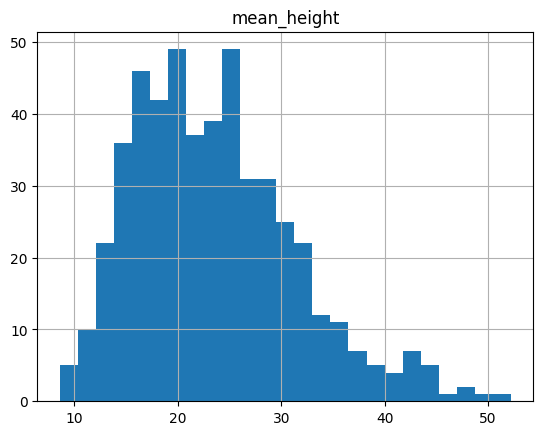

In [4]:
get_mean_hist(n=5, draws=500, bins=25)

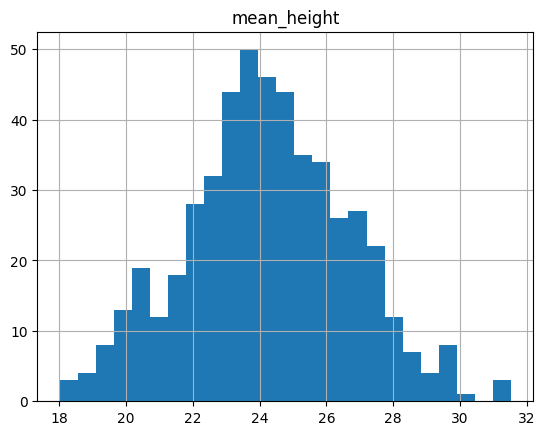

In [5]:
get_mean_hist(n=50, draws=500, bins=25)

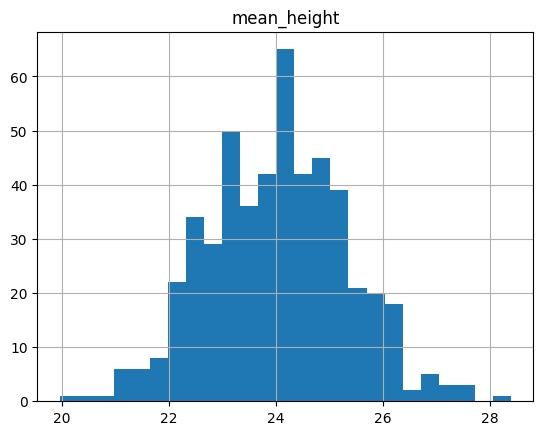

In [6]:
get_mean_hist(n=200, draws=500, bins=25)

The **Central Limit Theorem (CLT)** states that the distribution of sample means will approximate a normal distribution as the sample size increases, regardless of the shape of the original population distribution.

The three histograms above demonstrate this:

- **n=5, draws=500**: With only 5 trees per sample, the distribution of means is wide and somewhat rough. It begins to show a bell shape but still has noticeable irregularity — reflecting the skew seen in the `total_height` histogram from question 14.
- **n=50, draws=500**: With 50 trees per sample, the distribution of means is noticeably tighter and more symmetric, forming a clearer bell curve. The spread has decreased because averaging over more observations reduces variability.
- **n=200, draws=500**: With 200 trees per sample, the distribution is very tightly concentrated around the population mean and is almost perfectly normal.

In each case, `draws=500` means we repeated the sampling process 500 times — giving us 500 sample means to plot. This provides enough repetitions to see the shape of the sampling distribution clearly. The key variable driving the CLT is `n` (sample size): as `n` increases, the sampling distribution becomes more normal and its spread (standard error) decreases. This holds even though the original `total_height` distribution is not perfectly normal — that is the power of the CLT.